# **Time series forecasting model using LSTM neural networks**

---



In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense


In [35]:
df = pd.read_csv('AirPassengers.csv')
print(df.head())


     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121


In [36]:
# Parse dates
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)


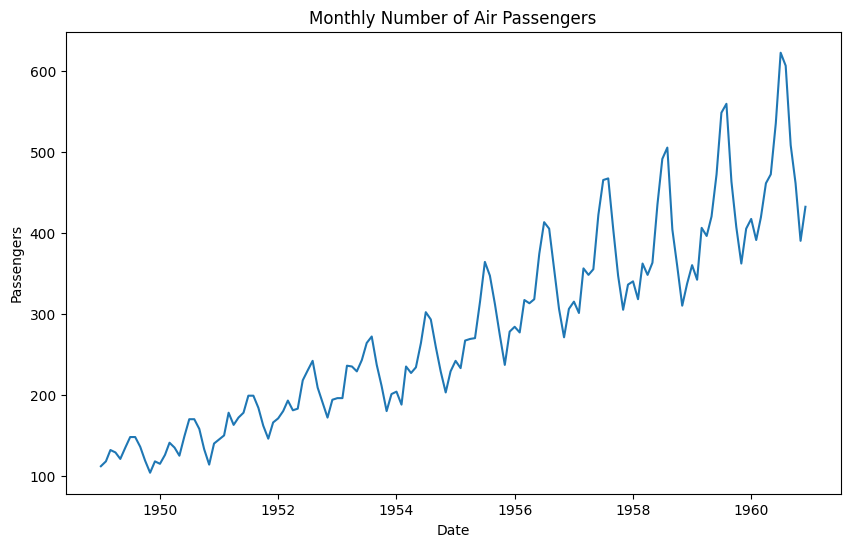

In [37]:
plt.figure(figsize=(10,6))
plt.plot(df)
plt.title('Monthly Number of Air Passengers')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.show()

In [38]:
# Preprocessing
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(df)

In [39]:
def create_sequences(data, seq_length):
    x = []
    y = []
    for i in range(seq_length, len(data)):
        x.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(x), np.array(y)
seq_length = 12  # 12 months
X, y = create_sequences(data_scaled, seq_length)

In [40]:
X = X.reshape((X.shape[0], X.shape[1], 1))

In [41]:
from keras.layers import LSTM, Dense, Input

model = Sequential()
model.add(Input(shape=(X.shape[1], 1)))
model.add(LSTM(units=50, activation='relu', return_sequences=True))
model.add(LSTM(units=50, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

In [42]:

history = model.fit(X, y, epochs=100, batch_size=16, verbose=1)

predicted = model.predict(X)

predicted = scaler.inverse_transform(predicted.reshape(-1, 1))
actual = scaler.inverse_transform(y.reshape(-1, 1))


Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1735
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0993
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0276
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0183
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0144
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0117
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0096
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0105
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0090
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0090
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0088
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0098
Epoch 13/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0106
Epoch 14/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0086
Epoch 15/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0078
Epoch 16/100
9/9 ━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step


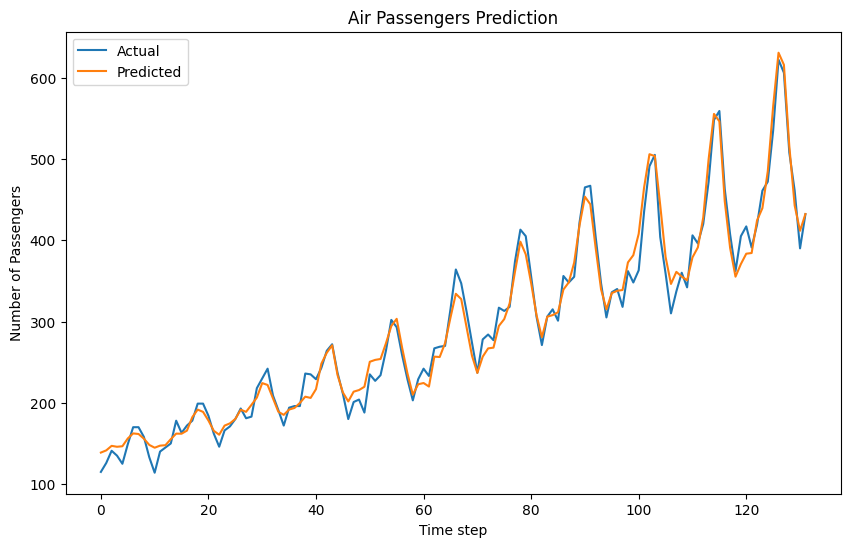

In [30]:
plt.figure(figsize=(10,6))
plt.plot(actual, label='Actual')
plt.plot(predicted, label='Predicted')
plt.title('Air Passengers Prediction')
plt.xlabel('Time step')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()